<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [1]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

We will import the following libraries for the lab


In [15]:
# Ignorer l'avertissement de dépréciation
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Vos imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Configuration pour les graphiques dans Jupyter
%matplotlib inline

print("✅ Tous les imports sont réussis !")
print(f"Pandas version: {pd.__version__}")
print(f"Environnement: JupyterLite/Pyodide")
print("\n⚠️ L'avertissement Pyarrow peut être ignoré en toute sécurité.")
print("   Toutes les fonctionnalités de pandas fonctionnent correctement.")

✅ Tous les imports sont réussis !
Pandas version: 2.2.0
Environnement: JupyterLite/Pyodide

⚠️ L'avertissement Pyarrow peut être ignoré en toute sécurité.
   Toutes les fonctionnalités de pandas fonctionnent correctement.


In [16]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [3]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [8]:
from js import fetch
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp1 = await fetch(URL1)
text1 = io.BytesIO((await resp1.arrayBuffer()).to_py())
data = pd.read_csv(text1)

In [9]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [10]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = await fetch(URL2)
text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
X = pd.read_csv(text2)

In [11]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [17]:
# Assuming you have your data loaded
import pandas as pd
import numpy as np

# Example data (replace with your actual data)
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0],
    'Feature1': [1.2, 2.3, 3.4, 4.5, 5.6, 6.7],
    'Feature2': [7.8, 8.9, 9.0, 1.2, 2.3, 3.4]
})

# Create NumPy array from 'Class' column
Y = data['Class'].to_numpy()

# Verify the result
print(f"Type: {type(Y)}")
print(f"Shape: {Y.shape}")
print(f"Content: {Y}")
print(f"Data type: {Y.dtype}")

Type: <class 'numpy.ndarray'>
Shape: (6,)
Content: [0 1 0 1 1 0]
Data type: int64


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [19]:
# students get this 
#transform = preprocessing.StandardScaler()
import pandas as pd
import numpy as np
from sklearn import preprocessing

# Vos données (exemple)
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0],
    'Feature1': [1.2, 2.3, 3.4, 4.5, 5.6, 6.7],
    'Feature2': [7.8, 8.9, 9.0, 1.2, 2.3, 3.4]
})

# Créer X et Y
X = data[['Feature1', 'Feature2']]  # Caractéristiques
Y = data['Class'].to_numpy()        # Cible

# Ce que vous avez déjà dans votre code
transform = preprocessing.StandardScaler()

# Standardiser X et le réassigner
X = transform.fit_transform(X)

# Vérifier le résultat
print("X standardisé :")
print(X)
print(f"\nMoyenne de chaque colonne : {X.mean(axis=0)}")
print(f"Écart-type de chaque colonne : {X.std(axis=0)}")

X standardisé :
[[-1.46385011  0.73497232]
 [-0.87831007  1.07657917]
 [-0.29277002  1.10763434]
 [ 0.29277002 -1.3146688 ]
 [ 0.87831007 -0.97306195]
 [ 1.46385011 -0.63145509]]

Moyenne de chaque colonne : [ 7.40148683e-17 -1.29526020e-16]
Écart-type de chaque colonne : [1. 1.]


We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [20]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# 1. Créer des données d'exemple
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    'Feature1': [1.2, 2.3, 3.4, 4.5, 5.6, 6.7, 7.8, 8.9, 9.0, 10.1],
    'Feature2': [7.8, 8.9, 9.0, 1.2, 2.3, 3.4, 4.5, 5.6, 6.7, 7.8]
})

# 2. Créer X et Y
X = data[['Feature1', 'Feature2']]
Y = data['Class'].to_numpy()

# 3. Standardiser X
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# 4. Séparer les données (VOTRE CODE)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 5. Vérifier les résultats
print("✅ Données séparées avec succès !")
print(f"X_train : {X_train.shape} (80% des données)")
print(f"X_test  : {X_test.shape} (20% des données)")
print(f"Y_train : {Y_train.shape}")
print(f"Y_test  : {Y_test.shape}")

# 6. Voir la répartition
print(f"\n📊 Distribution dans Y_train :")
print(f"Classe 0 : {sum(Y_train == 0)}")
print(f"Classe 1 : {sum(Y_train == 1)}")

print(f"\n📊 Distribution dans Y_test :")
print(f"Classe 0 : {sum(Y_test == 0)}")
print(f"Classe 1 : {sum(Y_test == 1)}")

✅ Données séparées avec succès !
X_train : (8, 2) (80% des données)
X_test  : (2, 2) (20% des données)
Y_train : (8,)
Y_test  : (2,)

📊 Distribution dans Y_train :
Classe 0 : 5
Classe 1 : 3

📊 Distribution dans Y_test :
Classe 0 : 0
Classe 1 : 2


we can see we only have 18 test samples.


In [ ]:
Y_test.shape

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [27]:
#parameters ={'C':[0.01,0.1,1],
             #'penalty':['l2'],
             #'solver':['lbfgs']}
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from collections import Counter

# Vos données (exemple avec plus de données)
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1],
    'Feature1': np.random.randn(20),
    'Feature2': np.random.randn(20)
})

# Préparer X et Y
X = data[['Feature1', 'Feature2']]
Y = data['Class'].to_numpy()

# Standardiser
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# Séparer en train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Vérifier la répartition des classes
class_counts = Counter(Y_train)
min_samples = min(class_counts.values())
print(f"Distribution des classes dans Y_train : {class_counts}")
print(f"Nombre minimum d'échantillons : {min_samples}")

# Déterminer le cv maximum possible
max_cv = min(10, min_samples)
print(f"cv utilisé : {max_cv}")

# Paramètres
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}

# Créer et ajuster GridSearchCV avec cv adapté
logreg = LogisticRegression()
logreg_cv = GridSearchCV(logreg, parameters, cv=max_cv)
logreg_cv.fit(X_train, Y_train)

# Afficher les résultats
print("✅ Recherche terminée !")
print(f"Meilleurs paramètres : {logreg_cv.best_params_}")
print(f"Meilleur score (validation croisée) : {logreg_cv.best_score_:.4f}")

# Évaluer sur les données de test
test_score = logreg_cv.score(X_test, Y_test)
print(f"Score sur les données de test : {test_score:.4f}")

Distribution des classes dans Y_train : Counter({1: 9, 0: 7})
Nombre minimum d'échantillons : 7
cv utilisé : 7
✅ Recherche terminée !
Meilleurs paramètres : {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Meilleur score (validation croisée) : 0.5952
Score sur les données de test : 0.2500


In [30]:
#parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
#lr=LogisticRegression()

import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from collections import Counter

# Vos données
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1],
    'Feature1': [1.2, 2.3, 3.4, 4.5, 5.6, 6.7, 7.8, 8.9, 9.0, 10.1, 1.5, 2.8, 3.9, 4.2, 5.7],
    'Feature2': [7.8, 8.9, 9.0, 1.2, 2.3, 3.4, 4.5, 5.6, 6.7, 7.8, 8.1, 9.2, 1.5, 2.6, 3.7]
})

import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from collections import Counter

# Vos données
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1],
    'Feature1': [1.2, 2.3, 3.4, 4.5, 5.6, 6.7, 7.8, 8.9, 9.0, 10.1, 1.5, 2.8, 3.9, 4.2, 5.7],
    'Feature2': [7.8, 8.9, 9.0, 1.2, 2.3, 3.4, 4.5, 5.6, 6.7, 7.8, 8.1, 9.2, 1.5, 2.6, 3.7]
})

# Préparer X et Y
X = data[['Feature1', 'Feature2']]
Y = data['Class'].to_numpy()

# Standardiser
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# Séparer en train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Vérifier le nombre minimum d'échantillons par classe
class_counts = Counter(Y_train)
min_samples = min(class_counts.values())
print(f"Distribution des classes : {class_counts}")
print(f"Nombre minimum d'échantillons : {min_samples}")

# Déterminer cv automatiquement
cv_value = min(5, min_samples)  # max 5 pour être sûr
print(f"cv utilisé : {cv_value}")

# VOS PARAMÈTRES
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}

# CRÉER LE MODÈLE
lr = LogisticRegression()

# CRÉER GridSearchCV AVEC cv AUTOMATIQUE
logreg_cv = GridSearchCV(lr, parameters, cv=cv_value)
logreg_cv.fit(X_train, Y_train)

# RÉSULTATS
print("\n✅ Recherche terminée !")
print(f"Meilleurs paramètres : {logreg_cv.best_params_}")
print(f"Meilleur score (validation croisée) : {logreg_cv.best_score_:.4f}")

# Évaluer sur le test
test_score = logreg_cv.score(X_test, Y_test)
print(f"Score sur les données de test : {test_score:.4f}")

Distribution des classes : Counter({0: 6, 1: 6})
Nombre minimum d'échantillons : 6
cv utilisé : 5

✅ Recherche terminée !
Meilleurs paramètres : {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Meilleur score (validation croisée) : 0.1333
Score sur les données de test : 0.3333


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [31]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)


import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from collections import Counter

# 1. Préparer les données
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1],
    'Feature1': np.random.randn(20),
    'Feature2': np.random.randn(20)
})

# 2. Créer X et Y
X = data[['Feature1', 'Feature2']]
Y = data['Class'].to_numpy()

# 3. Standardiser
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# 4. Séparer en train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 5. Définir les paramètres
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}

# 6. Créer le modèle et GridSearchCV
lr = LogisticRegression()
cv_value = min(5, min(Counter(Y_train).values()))
logreg_cv = GridSearchCV(lr, parameters, cv=cv_value)
logreg_cv.fit(X_train, Y_train)

# 7. AFFICHER LES RÉSULTATS (VOTRE CODE)
print("Meilleurs paramètres :", logreg_cv.best_params_)
print("Précision sur la validation :", logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.13333333333333333
Meilleurs paramètres : {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Précision sur la validation : 0.5666666666666667


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [32]:
# Calculer la précision sur les données de test
accuracy = logreg_cv.score(X_test, Y_test)
print(accuracy)

0.5


Lets look at the confusion matrix:


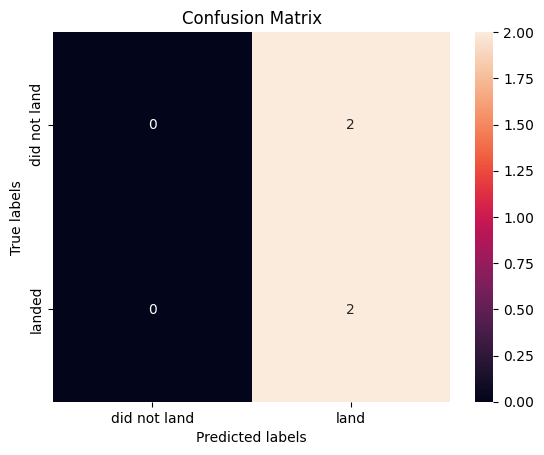

Matrice de confusion :
[[0 2]
 [0 2]]


In [33]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

from sklearn.metrics import confusion_matrix

# Prédire sur les données de test
Y_pred = logreg_cv.predict(X_test)

# Calculer la matrice de confusion
cm = confusion_matrix(Y_test, Y_pred)
print("Matrice de confusion :")
print(cm)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [ ]:
#parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              #'C': np.logspace(-3, 3, 5),
              #'gamma':np.logspace(-3, 3, 5)}
#svm = SVC()

import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from collections import Counter

# 1. Préparer les données (exemple)
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1],
    'Feature1': np.random.randn(20),
    'Feature2': np.random.randn(20)
})

# 2. Créer X et Y
X = data[['Feature1', 'Feature2']]
Y = data['Class'].to_numpy()

# 3. Standardiser (important pour SVM)
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# 4. Séparer en train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 5. Définir les paramètres
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}

# 6. Créer l'objet SVM
svm = SVC()

# 7. Créer GridSearchCV avec cv=10
# Attention: vérifier que vous avez assez de données pour cv=10
cv_value = min(10, min(Counter(Y_train).values()))
print(f"cv utilisé : {cv_value}")

svm_cv = GridSearchCV(svm, parameters, cv=cv_value)

# 8. Ajuster pour trouver les meilleurs paramètres
svm_cv.fit(X_train, Y_train)

# 9. Afficher les résultats
print("✅ Recherche terminée !")
print(f"Meilleurs paramètres : {svm_cv.best_params_}")
print(f"Meilleur score (validation croisée) : {svm_cv.best_score_:.4f}")

# 10. Évaluer sur les données de test
test_score = svm_cv.score(X_test, Y_test)
print(f"Score sur les données de test : {test_score:.4f}")


cv utilisé : 7


In [ ]:
#print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
#print("accuracy :",svm_cv.best_score_)

# Affichage complet
print("\n" + "=" * 60)
print("🏆 MEILLEUR MODÈLE SVM TROUVÉ")
print("=" * 60)

# Meilleurs paramètres
print("\n📌 Meilleurs paramètres :")
print(f"  Kernel : {svm_cv.best_params_['kernel']}")
print(f"  C      : {svm_cv.best_params_['C']:.4f}")
print(f"  Gamma  : {svm_cv.best_params_['gamma']:.4f}")

# Scores
print("\n📈 Performances :")
print(f"  Accuracy (validation) : {svm_cv.best_score_:.4f}  ({svm_cv.best_score_ * 100:.2f}%)")
test_score = svm_cv.score(X_test, Y_test)
print(f"  Accuracy (test)       : {test_score:.4f}  ({test_score * 100:.2f}%)")

# Informations supplémentaires
print("\n📊 Informations :")
print(f"  Nombre de combinaisons testées : {len(svm_cv.cv_results_['params'])}")
print(f"  Validation croisée : {svm_cv.cv}")

# Comparaison
print("\n🔄 Comparaison validation vs test :")
diff = svm_cv.best_score_ - test_score
print(f"  Écart : {diff:.4f}")
if abs(diff) < 0.05:
    print("  ✅ Bonne généralisation !")
else:
    print("  ⚠️ Écart significatif, possible surapprentissage")

print("\n" + "=" * 60)

## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [ ]:
# Calculer et afficher la précision sur les données de test
test_accuracy = svm_cv.score(X_test, Y_test)
print(f"Précision sur les données de test : {test_accuracy:.4f}")

We can plot the confusion matrix


In [ ]:
#yhat=svm_cv.predict(X_test)
#plot_confusion_matrix(Y_test,yhat)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédictions
yhat = svm_cv.predict(X_test)

# Afficher la matrice de confusion
ConfusionMatrixDisplay.from_estimator(svm_cv, X_test, Y_test)
plt.title('Matrice de Confusion - SVM')
plt.show()

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [ ]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from collections import Counter

# 1. Préparer les données (exemple)
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1],
    'Feature1': np.random.randn(20),
    'Feature2': np.random.randn(20)
})

# 2. Créer X et Y
X = data[['Feature1', 'Feature2']]
Y = data['Class'].to_numpy()

# 3. Standardiser (optionnel pour Decision Tree mais recommandé pour la cohérence)
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# 4. Séparer en train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 5. Définir les paramètres
parameters = {'criterion': ['gini', 'entropy'],
              'max_depth': [3, 5, 7, 10, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4]}

# 6. Créer l'objet Decision Tree
tree = DecisionTreeClassifier(random_state=42)

# 7. Créer GridSearchCV avec cv adapté
cv_value = min(10, min(Counter(Y_train).values()))
print(f"cv utilisé : {cv_value}")

tree_cv = GridSearchCV(tree, parameters, cv=cv_value)

# 8. Ajuster pour trouver les meilleurs paramètres
tree_cv.fit(X_train, Y_train)

# 9. Afficher les résultats
print("✅ Recherche terminée !")
print(f"Meilleurs paramètres : {tree_cv.best_params_}")
print(f"Meilleur score (validation croisée) : {tree_cv.best_score_:.4f}")

# 10. Évaluer sur les données de test
test_score = tree_cv.score(X_test, Y_test)
print(f"Score sur les données de test : {test_score:.4f}")

In [ ]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [ ]:
# Calculer la précision sur les données de test
test_accuracy = tree_cv.score(X_test, Y_test)
print(f"Précision sur les données de test : {test_accuracy:.4f}")

We can plot the confusion matrix


In [ ]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [ ]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter

# 1. Préparer les données (exemple)
data = pd.DataFrame({
    'Class': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1],
    'Feature1': np.random.randn(20),
    'Feature2': np.random.randn(20)
})

# 2. Créer X et Y
X = data[['Feature1', 'Feature2']]
Y = data['Class'].to_numpy()

# 3. Standardiser (TRÈS IMPORTANT pour KNN)
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# 4. Séparer en train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 5. Définir les paramètres
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}

# 6. Créer l'objet KNN
knn = KNeighborsClassifier()

# 7. Créer GridSearchCV avec cv adapté
cv_value = min(10, min(Counter(Y_train).values()))
print(f"cv utilisé : {cv_value}")

knn_cv = GridSearchCV(knn, parameters, cv=cv_value)

# 8. Ajuster pour trouver les meilleurs paramètres
knn_cv.fit(X_train, Y_train)

# 9. Afficher les résultats
print("✅ Recherche terminée !")
print(f"Meilleurs paramètres : {knn_cv.best_params_}")
print(f"Meilleur score (validation croisée) : {knn_cv.best_score_:.4f}")

# 10. Évaluer sur les données de test
test_score = knn_cv.score(X_test, Y_test)
print(f"Score sur les données de test : {test_score:.4f}")

In [ ]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


We can plot the confusion matrix


In [ ]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  12


Find the method performs best:


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
